# Flood-risk index for Mpumalanga, South Africa

## Introduction

This page shows a reproducable R script code for Mpumalanga's flood-risk areas. Mpumalanga, which is located in the eastern part of South Africa, is a province characterised by its distinct topographical features and summer-rainfall climate that makes it highly susceptible to, and regularly affected by, severe flooding events. In this section, will make a flood-risk index map for Mpumalanga by combinining **annual precipitation**, **slope**, and **elevation**. The map will classify the flood risks into five flood-risk zones using Jenks natural breaks.

## Data sources

- WorldClim (precipitation)
- GADM (country and provincial boundaries)
- elevatr (DEM)

## Packages used

- `geodata` — Download WorldClim monthly temperature and precipitation and GADM country and provincial boundaries.
- `terra` — Raster import, cropping, masking and raster reconstruction.
- `sf` — Vector (country boundary) handling and plotting overlays.
- `SPEI` — Thornthwaite PET implementation.
- `tidyverse` — Tidy data handling, reshaping, and visualisation.
- `colorspace` — Colour palettes for continuous maps.


Before we begin with the analyses, I first want to prevent warning messages from appearing on my code block. *This method can be ignored when you are using RStudio or base R to do your coding. I am only using it because I am using an R kernel in Jupyter Notebook.*

In [1]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

options(
  repr.plot.width  = 12,
  repr.plot.height = 7,
  repr.plot.res    = 150
)

# These options center our plots and gives them a better resolution than default. 
# These options are only for jupyter notebook. Ignore you use R and RStudio.

### Install packages

Before we begin with the analysis, we first have to install the required packages. **Make sure to install the packages you have not previously installed, and exclude those you have in the installation.**

In [ ]:
install.packages("geodata")
install.packages("terra")
install.packages("sf")
install.packages("elevatr")
install.packages("tidyverse")
install.packages("colorspace")
install.packages("classInt")

### Load libraries

In [3]:
library(terra)
library(sf)
library(geodata)
library(elevatr)
library(tidyverse)
library(colorspace)
library(classInt)     # Jenks natural breaks

options(scipen = 10)
terraOptions(progress = 1)

### Data acquisition and spatial preparation

Now that our libraries have been loaded, we will now download Mpumalanga's boundary via `geodata` as well as the monthly monthly precipitation (`prec`).

In [4]:
# Download provincial boundaries

zaf_admin1 <- geodata::gadm(country = "ZAF", level = 1, path = tempdir())
zaf_admin1_sf <- st_as_sf(zaf_admin1)

# Pick province by name

mp_name <- "Mpumalanga"
mp_sf <- zaf_admin1_sf %>% filter(NAME_1 == mp_name)

In [5]:
# Download WorldClim monthly precipitation

precipitation_global <- geodata::worldclim_global(var = "prec", res = 2.5, path = tempdir())

Next we will crop and mask the global precipitation layer to Mpumalanga. This ensures that the map does not show any information outside Mpumalanga's boundary.

In [6]:
# Crop & mask to province

precipitation_mp <- crop(precipitation_global, mp_sf) %>% mask(vect(mp_sf))

# Sum to annual precipitation (mm/year)

precipitation_annual_mp <- app(precipitation_mp, fun = sum, cores = 1)

Now we move on to the elevation data. We will fetch the digital elevation map (DEM) for Mpumalanga using the `elevatr` package and derive terrain metrics.

In [7]:
# Download elevatr elevation data
# elevatr requires a sf object in lon/lat

mp_latlon <- st_transform(mp_sf, 4326)

dem_r <- get_elev_raster(mp_latlon, z = 8, clip = "locations")   # returns a Raster*; convert to terra
dem_tr <- rast(dem_r)

Mosaicing & Projecting

Clipping DEM to locations



Note: Elevation units are in meters.



The following step involves computing the slope (in degrees) using `terra`'s terrain function.

In [8]:
# Compute slope

slope_mp <- terrain(dem_tr, v = "slope", unit = "degrees", neighbors = 8)

# Compute a simple TPI (topographic position index) as DEM - focal mean (window ~ 11x11 cells)
# Window size in cells: choose odd window; adapt to DEM resolution (we will use 11 as a reasonable default)

win <- 11
w <- matrix(1, nrow = win, ncol = win) / (win * win)
dem_focal_mean <- focal(dem_tr, w = w, fun = "mean", na.policy = "omit", na.rm = TRUE)
tpi_mp <- dem_tr - dem_focal_mean

# Negative TPI -> local pit/valley -> more likely to accumulate water. We'll use -TPI as a positive risk contributor.

# Low elevation tends to be flood-prone (river valleys/coastal plains). Use DEM inverted.

elevation_mp <- dem_tr

# Align climate raster and terrain rasters to the same extents/resolutions.
# Resample terrain layers to the precipitation grid for consistent cell alignment (use bilinear)

target <- precipitation_annual_mp
slope_rs <- resample(slope_mp, target, method = "bilinear")
tpi_rs   <- resample(tpi_mp, target, method = "bilinear")
elevation_rs  <- resample(elevation_mp, target, method = "bilinear")

### Build a simple flood-risk index (equal-weighted, normalized layers)

The flood-risk index map layers are designed to show that risks increase with:

- **Annual precipitation** : higher precipitation = higher flood potential
- **Negative TPI (valleys)** : more negative TPI -> more accumulation -> higher risk
- **Low slope (gentle slopes)** : higher flood potential (we use the inverse of slope)
- **Low elevation** : higher flood potential (inverse of elevation)


The following step to making our map is to build a helper function to scale the raster to handle NA values:

In [9]:
# Helper function to scale raster to 0..1 (handles NA)

scale0_1 <- function(r) {
  v <- values(r)
  mn <- min(v, na.rm = TRUE)
  mx <- max(v, na.rm = TRUE)
  if (is.na(mn) || is.na(mx) || mx == mn) {
    return(setValues(r, NA_real_))
  }
  (r - mn) / (mx - mn)
}

In [10]:
# Normalize layers

precipitation_norm  <- scale0_1(precipitation_annual_mp) # Higher -> more risk
tpi_neg    <- (-1) * tpi_rs                              # Valleys positive
tpi_norm   <- scale0_1(tpi_neg)
slope_inv  <- 1 - scale0_1(slope_rs)                     # Low slope -> high risk
elevation_inv   <- 1 - scale0_1(elevation_rs)            # Low elevation -> high risk

# Combine with equal weights into a continuous flood risk index (0..1)

risk_stack <- c(precipitation_norm, tpi_norm, slope_inv, elevation_inv)
names(risk_stack) <- c("precipitation", "tpi", "slope_inv", "elevation_inv")
flood_index <- app(risk_stack, fun = function(v) {
  if (all(is.na(v))) return(NA_real_)
  mean(v, na.rm = TRUE)
})

names(flood_index) <- "flood_index"

### Classify index into 5 zones using Jenks natural breaks

In [37]:
# Extract values for classification

vals <- values(flood_index)
vals_nonNA <- vals[!is.na(vals)]

# Compute Jenks breaks (5 classes)

n_classes <- 5
jenks <- classInt::classIntervals(vals_nonNA, n = n_classes, style = "fisher")
breaks <- jenks$brks

# Assign classes (1 -> 5) to raster

flood_class <- classify(flood_index, rbind(
  c(-Inf, breaks[2], 1),
  c(breaks[2], breaks[3], 2),
  c(breaks[3], breaks[4], 3),
  c(breaks[4], breaks[5], 4),
  c(breaks[5], Inf, 5)
))
names(flood_class) <- "flood_class"

# Create a data.frame for plotting (drop NAs)

df_map <- as.data.frame(flood_class, xy = TRUE, na.rm = TRUE)
colnames(df_map)[3] <- "flood_class"
df_map$flood_class <- factor(df_map$flood_class, levels = 1:5,
                            labels = c("Very low", "Low", "Moderate", "High", "Very high"))

Warning message in classInt::classIntervals(vals_nonNA, n = n_classes, style = "fisher"):
"N is large, and some styles will run very slowly; sampling imposed"


### Plot map

Before we plot the map, we will assign a colour palette to the map which shows higher risk levels with darker colours:

In [12]:
pal <- rev(sequential_hcl(5, palette = "Reds"))  # higher risk -> darker red

Now we will plot the final map:

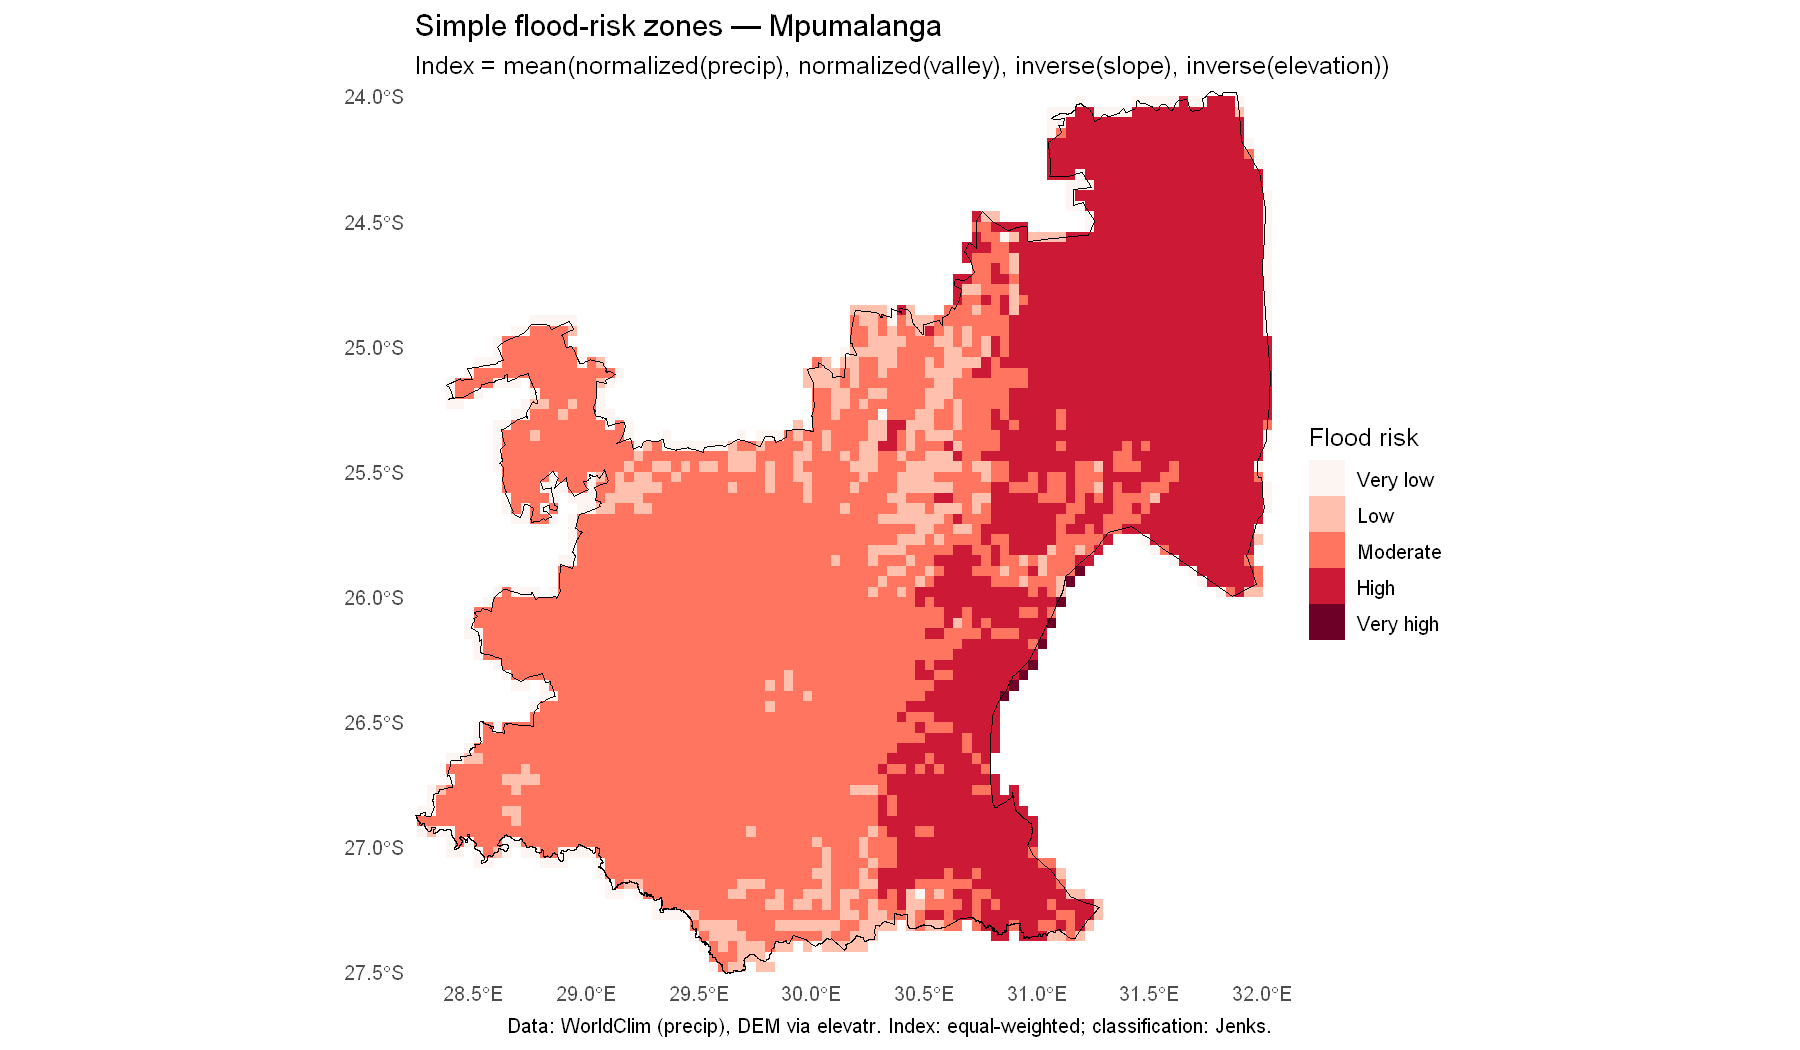

In [38]:
ggplot() +

# Add flood-risk raster

geom_raster(data = df_map, aes(x = x, y = y, fill = flood_class)) +

# Add Mpumalanga provincial boundary

geom_sf(data = mp_sf, fill = NA, colour = "black", size = 0.3) +

# Add map coordinates

coord_sf(expand = FALSE) +

# Add colour gradient

scale_fill_manual(values = pal, name = "Flood risk") +

# Add map labels

labs(title = paste("Simple flood-risk zones —", mp_name),
     subtitle = "Index = mean(normalized(precip), normalized(valley), inverse(slope), inverse(elevation))",
     caption = "Data: WorldClim (precip), DEM via elevatr. Index: equal-weighted; classification: Jenks.") +

# Add map theme

theme_minimal(base_size = 12) +
theme(panel.grid = element_blank(), axis.title = element_blank())

### Touch-ups

The map looks too pixelated for my liking, however it is because we used global raster's instead of the Mpumalanga municipality's rasters, or something local scale. I would advice you to look for higher resolution data (< 30 m or 10 m pixels) for your country or province if you plan on making publishable maps or more professional maps. Moreover, this map on its own only shows us areas more prone to floods in Mpumalanga, it is still missing key layers to people unfamiliar to Mpumalanga. We will add municipal boundaries and municipality-level statistics (area share of each flood-risk class), and compose a final map with the flood‑risk raster, municipal boundaries, and a small inset bar chart showing the municipalities with the largest percent area classified as "Very high" flood risk.

In [15]:
# Load libraries

library(cowplot) # Insert inset bar graph on the map
library(ggrepel) # Properly position overlapping texts on map

# Download municipality boundaries (GADM level 2) and extract only Mpumalanga municipalities

gadm2 <- geodata::gadm(country = "ZAF", level = 2, path = tempdir())
gadm2_sf <- st_as_sf(gadm2)

# Keep same CRS for joins

gadm2_sf <- st_transform(gadm2_sf, st_crs(mp_sf))

# Filter municipalities that lie inside Mpumalanga (NAME_1 matches mp_name)

munis_mp <- gadm2_sf %>% filter(NAME_1 == mp_name)
if (nrow(munis_mp) == 0) stop("No level-2 municipalities found for Mpumalanga; check GADM NAME_1 field.")

In [16]:
# Convert pixel table to sf points and spatially join to municipalities

pts_sf <- st_as_sf(df_map, coords = c("x", "y"), crs = st_crs(munis_mp))
pts_muni <- st_join(pts_sf, munis_mp["NAME_2"], left = FALSE) # Keep only points inside municipalities

In [17]:
# Compute municipality-level class counts & percent area (pixel counts proportional to area since grid regular)

muni_counts <- pts_muni %>%
  st_drop_geometry() %>%
  group_by(NAME_2, flood_class) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(NAME_2) %>%
  mutate(total = sum(n), pct = 100 * n / total) %>%
  ungroup()

**From here we create a summary table which shows the percent of each municipality in "High" class and `mean flood_index`.**

In [18]:
high_pct <- muni_counts %>%
  filter(flood_class == "High") %>%
  select(NAME_2, pct_high = pct)

Compute `mean flood_index` per municipality and convert Mpumalanga (mp) polygons to terra format, run extract, then aggregate.

In [19]:
r <- flood_index
muni_vect <- terra::vect(munis_mp)   # Convert sf to SpatVector
ext <- terra::extract(r, muni_vect, fun = mean, na.rm = TRUE)

# ext rows are in the same order as muni_vect

ext_df <- tibble::tibble(
  NAME_2 = munis_mp$NAME_2,
  mean_index = ext[[2]]   # Second column holds the aggregated mean
)

# Left join percent-very-high (precomputed) and produce muni_summary

muni_summary <- ext_df %>%
  left_join(high_pct, by = "NAME_2") %>%
  mutate(pct_high = tidyr::replace_na(pct_high, 0))

# Quick check: show top municipalities by percent very-high

top_munis <- muni_summary %>% arrange(desc(pct_high)) %>% slice_head(n = 10)
print(top_munis)

# A tibble: 3 × 3               
  NAME_2       mean_index pct_high
  <chr>             <dbl>    <dbl>
1 Ehlanzeni         0.603   73.3  
2 Gert Sibande      0.532   22.4  
3 Nkangala          0.510    0.462


Now that we have computed the `mean flood_index` per municipality and the summary table, we can visualise the results on a bar graph, which we will then attach to the main map.

In [20]:
# Build bar chart inset (horizontal bar)

bar_df <- top_munis %>% select(NAME_2, pct_high) %>% arrange(pct_high)

bar_plot <- ggplot(bar_df, aes(x = pct_high, y = reorder(NAME_2, pct_high))) +
  geom_col(fill = sequential_hcl(nrow(bar_df), "Reds")[nrow(bar_df):1]) +
  labs(x = "% area (High)", y = NULL, title = "Top municipalities: % area High risk") +
  theme_minimal(base_size = 9) +
  theme(panel.grid.major.y = element_blank(), plot.title = element_text(size = 10))

In [21]:
# Create municipality outline layer for map (light borders)

muni_borders <- st_union(munis_mp) # Single geometry used only for plotting area border if needed

### Prepare main map

In [39]:
# Add colour palette

pal <- rev(sequential_hcl(5, palette = "Reds"))

# Add flood_class raster + municipalities boundaries

main_map <- ggplot() +
  geom_raster(data = df_map, aes(x = x, y = y, fill = flood_class)) +
  geom_sf(data = munis_mp, fill = NA, colour = "gray20", size = 0.25) +
  geom_sf(data = mp_sf, fill = NA, colour = "black", size = 0.4) +
  coord_sf(expand = FALSE) +
  scale_fill_manual(values = pal, name = "Flood risk") +
  labs(title = paste("Flood-risk zones with municipalities —", mp_sf$NAME_1[1]),
       subtitle = "Municipal outlines show administrative units; inset ranks municipalities by % area 'High' risk",
       caption = "Index = mean(normalized precip, valley, inverse slope, inverse elevation). Classification: Jenks.") +
  theme_minimal(base_size = 12) +
  theme(panel.grid = element_blank(), axis.title = element_blank())

In [40]:
# Add labels for the top municipalities on the map (centroids)

centroids <- st_centroid(munis_mp)
labels_df <- centroids %>%
  st_drop_geometry() %>%
  right_join(top_munis %>% select(NAME_2, pct_high), by = "NAME_2")

main_map_labeled <- main_map +
  geom_text(data = labels_df, aes(x = st_coordinates(centroids)[,1],
                                  y = st_coordinates(centroids)[,2],
                                  label = NAME_2),
            size = 3, fontface = "bold", colour = "black")

Warning message:
"st_centroid assumes attributes are constant over geometries"


In [41]:
# Download South Africa boundary

south_africa_boundary <- geodata::gadm(country = "ZAF", level = 0, path = tempdir())

# Convert boundary to sf for plotting

south_africa_sf   <- st_as_sf(south_africa_boundary)

# Add inset map of South Africa

inset_plot <- ggplot() +
  geom_sf(data = south_africa_sf, fill = "gray90", colour = "gray60", size = 0.15) +   # whole country background
  geom_sf(data = mp_sf, fill = "#E41A1C", colour = "black", size = 0.3, alpha = 0.7) + # highlighted province

  # small border and minimal theme, no axes/ticks

  coord_sf(expand = FALSE) +
  theme_void() +
  theme(panel.background = element_rect(fill = "white", colour = "black", linewidth = 0.35), plot.margin = margin(2, 2, 2, 2))

Now that all the preparations have been done, we will visualise our final figure with inset bar chart (top-right)

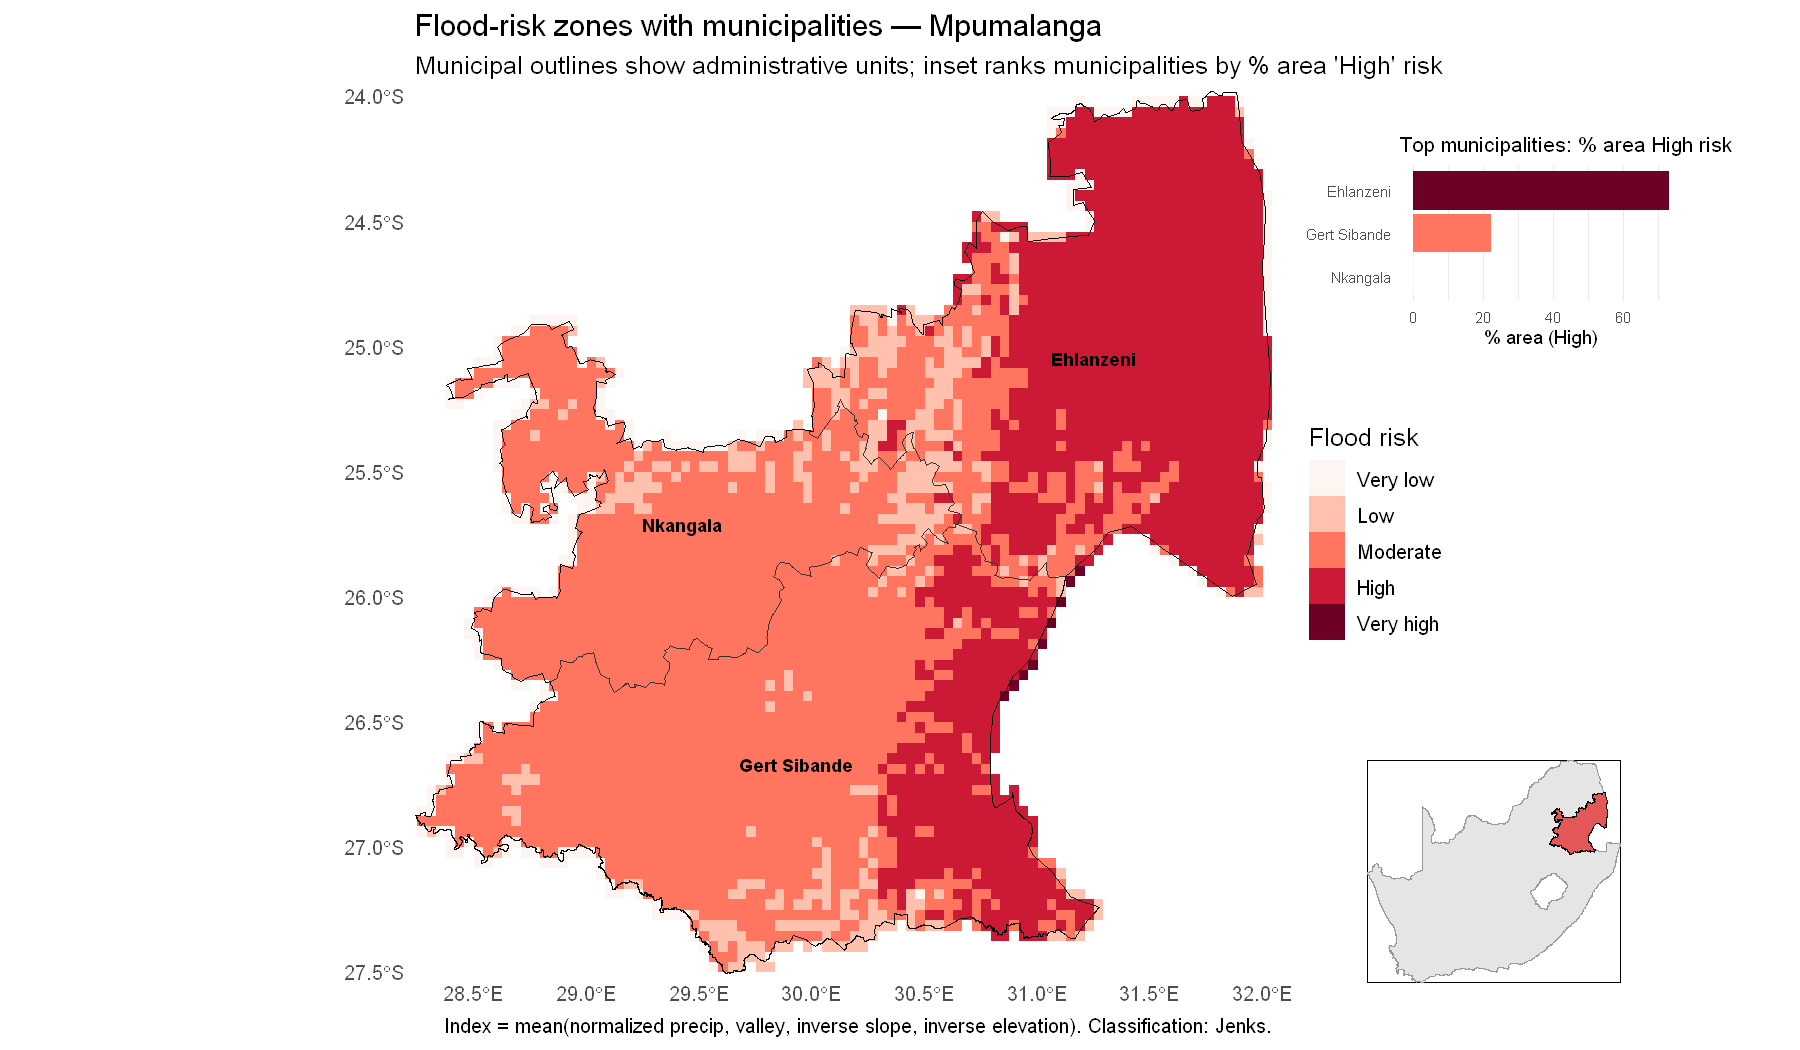

In [42]:
final_plot <- ggdraw() +
  draw_plot(main_map_labeled, 0, 0, 1, 1) +
  draw_plot(bar_plot, 0.72, 0.66, 0.22, 0.22) + # Adjust placement/size as desired (Horizontal movement, vertical movement, width, height)
  draw_plot(inset_plot, 0.72, 0.06, 0.22, 0.22) # Adjust placement/size as desired (Horizontal movement, vertical movement, width, height)

# Display final plot and a small table
print(final_plot)

### Interpretation

I made this map after recent flooding events that occured in Mpumalanga (January 2026). The goal was to see the areas which are most prone to flooding events in the province. This map shows us a clear contrast in flood potential across Mpumalanga, with the narrow coastal/lowland corridor and the eastern low‑relief valley systems dominated by the darkest classes (“High” / “Very high”), while much of the interior and higher, steeper ground is classified as “Moderate” to “Very low.” At the municipal scale the inset bar chart attached makes the pattern quantitative. Ehlanzeni munisipality has by far the largest share of its area in the highest risk class, Gert Sibande has a moderate fraction, and Nkangala only a small proportion. 

The high‑risk band coincides with cells that have relatively large annual precipitation, concave topographic position (valleys that collect flow), gentle slopes and lower elevation, a combination that promotes surface ponding, saturation and overbank flow during heavy rains. These areas are therefore the most likely to generate rapid runoff, elevated baseflow after storms, and localised inundation that can damage infrastructure and overwhelm drainage systems. 

Those same valley and floodplain zones also typically host wetlands, riparian vegetation and seasonally saturated soils that can support distinctive plant and animal communities and provide important ecosystem services such as sediment trapping and flood attenuation. Converting or degrading such areas (be it for agriculture, roads or urban expansion) can increase downstream flood hazard and erode biodiversity values. 

The map as you followed through while making it, is a rapid screening product which was equal‑weighted and Jenks‑classified. It is useful for prioritizing municipalities and sites for more detailed studies, but it does not replace process‑based hydraulic or soil‑infiltration modelling. The result of this map is influenced by its input resolution (the pixelation you see), the DEM zoom choice and the omission of factors like rainfall intensity, land cover, channel routing and soil infiltration. For decision making, the map suggests where to focus monitoring, local floodplain mapping and mitigation (retention, early warning, riparian protection) and where to commission finer‑scale hydrologic and hydraulic analyses.

**_Thank you for your time_**

If by any chance you do not like how pixelated the map is, there is a method for minimising the pixelation, however, I would advice that this method be used only for presentation/visualisation and not for scientific claims. This methods is the upsampling method, which applies a smoothing filter (focal/Gaussian) that makes the image visually smooth. It does **NOT** add real information.

In [35]:
# Upsample (disaggregate) by integer factor (e.g., factor = 6 => ~6x finer cells)

fact <- 6
flood_index_ups <- disagg(flood_index, fact = fact, method = "bilinear")  # creates a higher-res raster

# Smooth: focal mean with a 5x5 kernel (or Gaussian-like weights)

kernel <- matrix(1, 5, 5)
kernel <- kernel / sum(kernel)
flood_index_smooth <- focal(flood_index_ups, w = kernel, fun = mean, na.rm = TRUE)

# Reclassify using same breaks (recompute Jenks on smoothed values or reuse earlier breaks)

vals <- values(flood_index_smooth); vals <- vals[!is.na(vals)]
brks <- classInt::classIntervals(vals, n = 5, style = "fisher")$brks
flood_class_smooth <- classify(flood_index_smooth, rbind(
  c(-Inf, brks[2], 1),
  c(brks[2], brks[3], 2),
  c(brks[3], brks[4], 3),
  c(brks[4], brks[5], 4),
  c(brks[5], Inf, 5)
))

# Plot the smoothed classification (will look much less blocky)
df_smooth <- as.data.frame(flood_class_smooth, xy = TRUE, na.rm = TRUE)

Warning message in classInt::classIntervals(vals, n = 5, style = "fisher"):
"N is large, and some styles will run very slowly; sampling imposed"


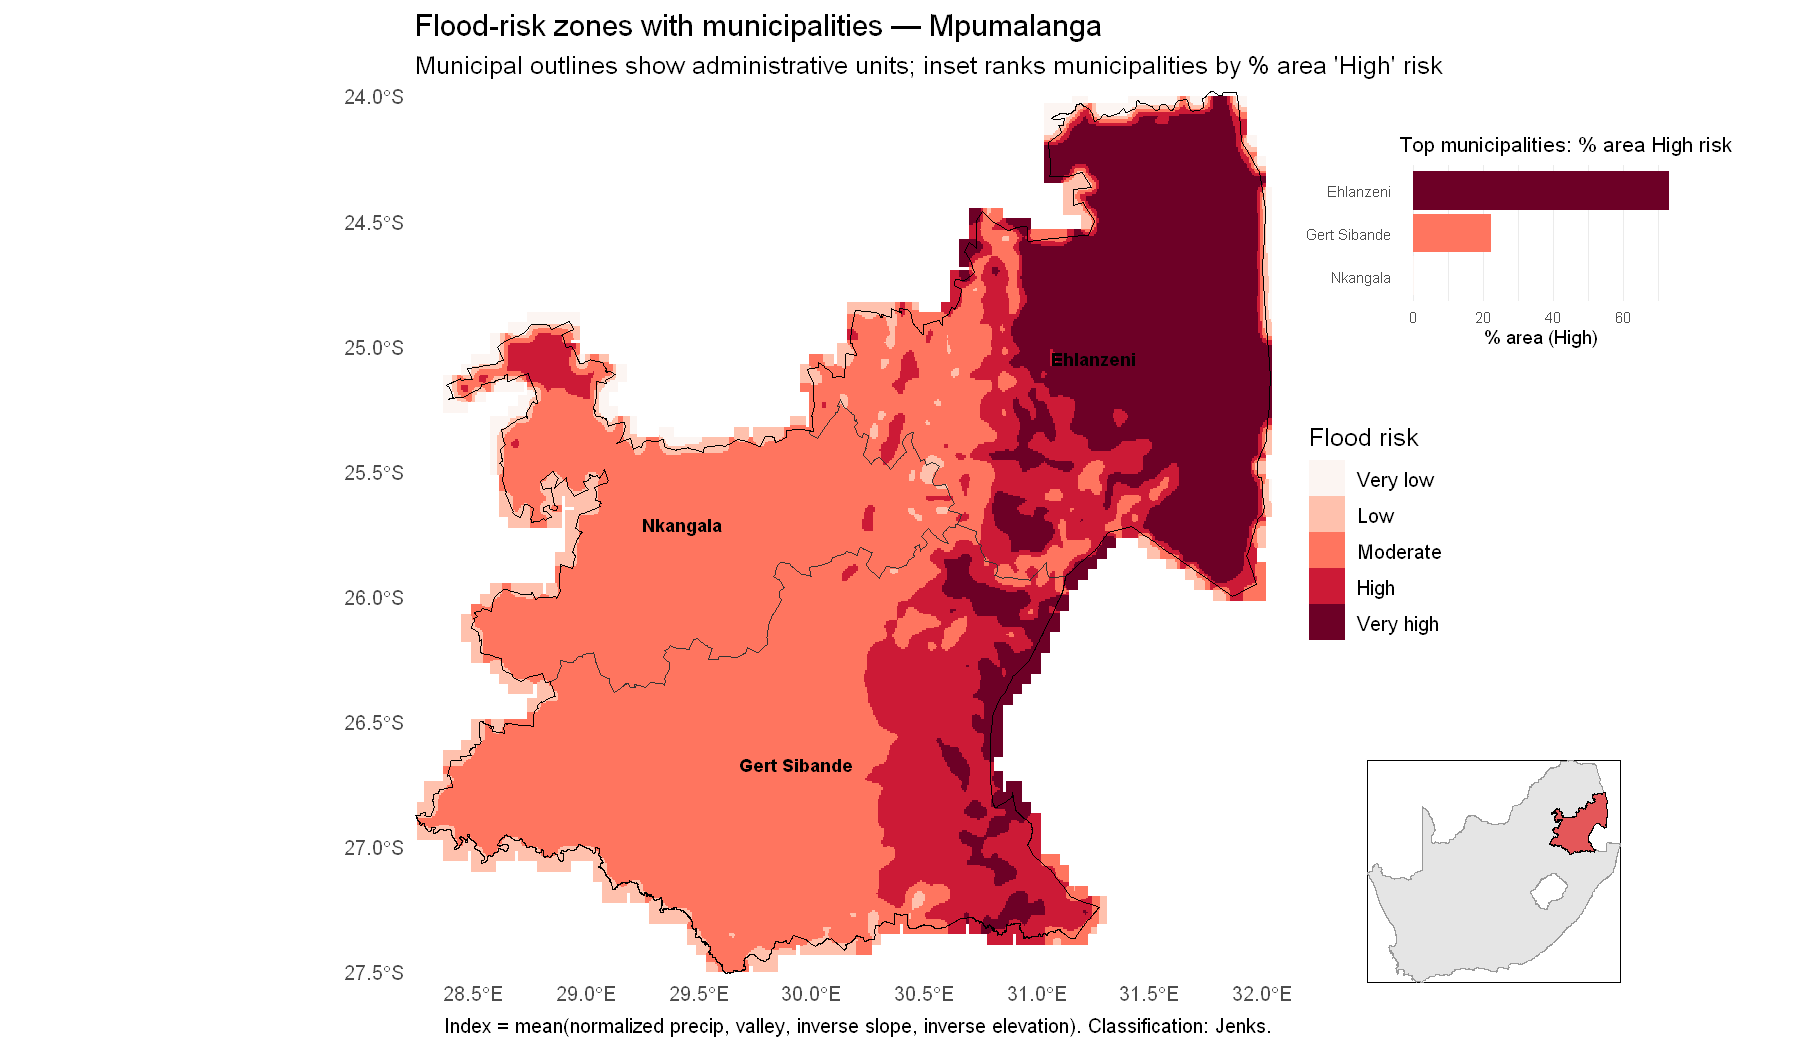

In [36]:
# Ensure df_smooth exists and flood_class is a factor with labels
colnames(df_smooth)[3] <- "flood_class"
df_smooth$flood_class <- factor(df_smooth$flood_class,
                                levels = 1:5,
                                labels = c("Very low","Low","Moderate","High","Very high"))

pal <- rev(sequential_hcl(5, "Reds"))

# Plot the smooth map

main_map2 <- ggplot() +
  geom_raster(data = df_smooth, aes(x = x, y = y, fill = flood_class)) +
  geom_sf(data = munis_mp, fill = NA, colour = "gray20", size = 0.25) +
  geom_sf(data = mp_sf, fill = NA, colour = "black", size = 0.4) +
  coord_sf(expand = FALSE) +
  scale_fill_manual(values = pal, name = "Flood risk") +
  labs(title = paste("Flood-risk zones with municipalities —", mp_sf$NAME_1[1]),
       subtitle = "Municipal outlines show administrative units; inset ranks municipalities by % area 'High' risk",
       caption = "Index = mean(normalized precip, valley, inverse slope, inverse elevation). Classification: Jenks.") +
  theme_minimal(base_size = 12) +
  theme(panel.grid = element_blank(), axis.title = element_blank())

# Add labels to the smooth map

main_map_labeled2 <- main_map2 +
  geom_text(data = labels_df, aes(x = st_coordinates(centroids)[,1],
                                  y = st_coordinates(centroids)[,2],
                                  label = NAME_2),
            size = 3, fontface = "bold", colour = "black")

# Compute final smooth map

smooth_final_plot <- ggdraw() +
  draw_plot(main_map_labeled2, 0, 0, 1, 1) +
  draw_plot(bar_plot, 0.72, 0.66, 0.22, 0.22) + # Adjust placement/size as desired (Horizontal movement, vertical movement, width, height)
  draw_plot(inset_plot, 0.72, 0.06, 0.22, 0.22) # Adjust placement/size as desired (Horizontal movement, vertical movement, width, height)

# Display final plot and a small table
print(smooth_final_plot)

### Comments

Already you can tell the difference between the upsampled version and the normal version of the maps. They look different because they were produced by two different processes, the first image shows the classification at the raster’s original resolution (the original “pixelated” output), while the second image is an upsampled + smoothed version of that same classification. In other words, the pixelated map is a faithful depiction of the data and grid which the index was actually computed while the smooth map above is a filtered presentation derived from that grid **(it looks nicer because the hard block edges are removed, but it does not add new measured information)**.

For analysis and any quantitative work (area statistics, municipal rankings, model validation, decisions about engineering or planning) you should use the original, native‑resolution raster or run the index at legitimately higher input resolution. The original raster is “correct” for the data computed, it honestly shows where each grid cell falls into each class and preserves the spatial support and uncertainty of those data. Using it avoids inventing spatial detail that our inputs did not actually provide. The upsampled/smoothed map is appropriate only for visual presentation (figures in slides, handouts) when you explicitly state that smoothing/upsampling was applied. It is not correct to treat the smoothed map as higher‑resolution evidence because the smoothing only fills gaps between coarse cells by interpolation and averaging, which can create the false impression of precise, sub‑pixel spatial structure that was never measured, just as as you can see with the "Very high" flood-risk shade being added.